## Домашка

### Задание 1 (8 баллов)
Обучите модель с минимум 15 слоями, где у каждого слоя разные параметры (Dropout, Conv1d и Pooling, Linear считаются слоями, остальное нет, но их тоже можно использовать). Как минимум 4 слоя должны быть наложены друг на друга и как минимум 2 параллельных слоя (последовательности слоев). Должен быть хотя бы один слой каждого типа.

Вместо графиков f1 меры сделайте графики для точности и полноты. Пообучайте модель подольше, чтобы посмотреть на то как изменяются метрики.

Напишите короткую функцию для предсказания класса отдельного текста. Возьмите любой новый новостной текст и предскажите его класс. Правильное ли предсказание?

Советы: Начните с небольших сетей и постепенно добавляйте слои и увеличивайте параметры, не пытайтесь сразу собрать все слои. Иногда кернел может крашиться просто так или из-за слишком больших матриц. Помимо уменьшения параметров, вы можете попробовать уменьшить batch size.



Epoch 1/15


  0%|          | 0/330 [00:00<?, ?it/s]

Train Acc: 0.2613 | Val Acc: 0.3616
Train Recall: 0.0903 | Val Recall: 0.1477

Epoch 2/15


  0%|          | 0/330 [00:00<?, ?it/s]

Train Acc: 0.4622 | Val Acc: 0.5072
Train Recall: 0.1896 | Val Recall: 0.2250

Epoch 3/15


...

Train Acc: 0.8093 | Val Acc: 0.7196
Train Recall: 0.4845 | Val Recall: 0.4260

Epoch 14/15


  0%|          | 0/330 [00:00<?, ?it/s]

Train Acc: 0.8198 | Val Acc: 0.7060
Train Recall: 0.4969 | Val Recall: 0.4221

Epoch 15/15


  0%|          | 0/330 [00:00<?, ?it/s]

Train Acc: 0.8297 | Val Acc: 0.7214
Train Recall: 0.5103 | Val Recall: 0.4338


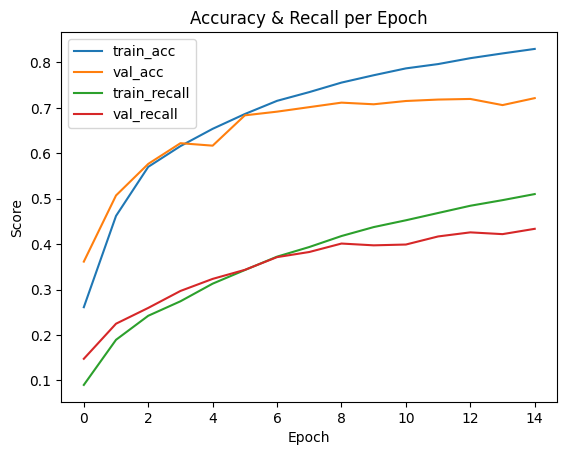

Predicted class: Россия


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score
from collections import Counter
from string import punctuation
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

df = pd.read_csv('/content/lenta_40k.csv')
df.dropna(subset=['topic', 'text'], inplace=True)

all_labels = sorted(set(df['topic']))
label2id = {label: idx for idx, label in enumerate(all_labels)}
id2label = {idx: label for label, idx in label2id.items()}

targets = [label2id[label] for label in df['topic']]

def preprocess(text):
    tokens = text.lower().split()
    tokens = [t.strip(punctuation) for t in tokens if t.strip(punctuation)]
    return tokens

vocab = Counter()
for text in df['text']:
    vocab.update(preprocess(text))

filtered_vocab = {w for w, c in vocab.items() if c > 30}
word2id = {'PAD': 0}
for word in filtered_vocab:
    word2id[word] = len(word2id)
id2word = {idx: w for w, idx in word2id.items()}

MAX_LEN = 200

class NewsDataset(Dataset):
    def __init__(self, texts, targets, word2id, max_len):
        self.texts = [
            torch.LongTensor([word2id[w] for w in preprocess(t) if w in word2id][:max_len])
            for t in texts
        ]
        self.texts = nn.utils.rnn.pad_sequence(self.texts, batch_first=True)
        self.targets = torch.LongTensor(targets)
        self.max_len = max_len

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return self.texts[idx], self.targets[idx]

train_texts, valid_texts, train_targets, valid_targets = train_test_split(
    df['text'].values, targets, test_size=0.05, random_state=42
)

train_dataset = NewsDataset(train_texts, train_targets, word2id, MAX_LEN)
valid_dataset = NewsDataset(valid_texts, valid_targets, word2id, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=128, shuffle=False)

class ConvBNDropout(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, dropout_p=0.1):
        super().__init__()
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size, padding=kernel_size//2)
        self.bn = nn.BatchNorm1d(out_channels)
        self.act = nn.LeakyReLU()
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.act(x)
        x = self.dropout(x)
        return x

class BigClf(nn.Module):
    def __init__(self, output_dim, vocab_size, emb_dim=100, max_len=200):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.emb_dropout = nn.Dropout(0.2)

        self.conv_a1 = ConvBNDropout(emb_dim, 64, kernel_size=3, dropout_p=0.1)
        self.conv_a2 = ConvBNDropout(64, 32, kernel_size=5, dropout_p=0.15)

        self.conv_b1 = ConvBNDropout(emb_dim, 32, kernel_size=7, dropout_p=0.1)
        self.conv_b2 = ConvBNDropout(32, 16, kernel_size=3, dropout_p=0.15)

        self.conv_c1 = ConvBNDropout(48, 64, kernel_size=3, dropout_p=0.2)
        self.pool1 = nn.MaxPool1d(2)
        self.conv_c2 = ConvBNDropout(64, 32, kernel_size=3, dropout_p=0.2)
        self.pool2 = nn.MaxPool1d(2)

        flattened_size = (max_len // 4) * 32
        self.fc1 = nn.Linear(flattened_size, 128)
        self.dropout_fc1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 64)
        self.dropout_fc2 = nn.Dropout(0.2)
        self.fc_out = nn.Linear(64, output_dim)
        self.act = nn.LogSoftmax(dim=1)

    def forward(self, text):
        x = self.embedding(text)
        x = self.emb_dropout(x)
        x = x.permute(0, 2, 1)

        a = self.conv_a2(self.conv_a1(x))
        b = self.conv_b2(self.conv_b1(x))
        x = torch.cat([a, b], dim=1)

        x = self.conv_c2(self.pool1(self.conv_c1(x)))
        x = self.pool2(x)

        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout_fc1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout_fc2(x)
        x = self.fc_out(x)
        return self.act(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BigClf(output_dim=len(label2id), vocab_size=len(word2id)).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.NLLLoss()

def train_epoch(model, loader):
    model.train()
    all_preds, all_labels = [], []
    for texts, labels in tqdm(loader, leave=False):
        texts, labels = texts.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(texts)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        preds = outputs.argmax(1).detach().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds, average='macro')
    return acc, recall

def eval_epoch(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for texts, labels in loader:
            texts, labels = texts.to(device), labels.to(device)
            outputs = model(texts)
            preds = outputs.argmax(1).detach().cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds, average='macro')
    return acc, recall

train_accs, val_accs, train_recalls, val_recalls = [], [], [], []

for epoch in range(15):
    print(f"\nEpoch {epoch+1}/15")
    train_acc, train_recall = train_epoch(model, train_loader)
    val_acc, val_recall = eval_epoch(model, valid_loader)
    print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    print(f"Train Recall: {train_recall:.4f} | Val Recall: {val_recall:.4f}")
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    train_recalls.append(train_recall)
    val_recalls.append(val_recall)

plt.plot(train_accs, label='train_acc')
plt.plot(val_accs, label='val_acc')
plt.plot(train_recalls, label='train_recall')
plt.plot(val_recalls, label='val_recall')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('Accuracy & Recall per Epoch')
plt.legend()
plt.show()

def predict(text, model, word2id, id2label, max_len=200):
    model.eval()
    tokens = [w for w in preprocess(text) if w in word2id]
    ids = [word2id[w] for w in tokens][:max_len]
    ids = ids + [0] * (max_len - len(ids))
    x = torch.LongTensor([ids]).to(device)
    with torch.no_grad():
        output = model(x)
        pred = output.argmax(1).item()
    return id2label[pred]

new_text = "В Москве планируют открыть новый спортивный комплекс для молодежи."
pred_class = predict(new_text, model, word2id, id2label)
print("Predicted class:", pred_class)


Задание 2 (2 балла)
Обучите нейросеть со сверточными слоями с архитектурой похожей на Unet - https://en.wikipedia.org/wiki/U-Net Вы можете работать как с текстами так и с картинками.

Не нужно воспроизводить все в точности, главное, чтобы было сокращение длины последовательности (или height, weight в картинках) с помощью CNN, а затем обратное увеличение до изначальной с residual связями между промежуточными шагами с одинаковыми размерностями. Изменений размерности должно быть хотя бы 3 и соответственно residual связей тоже.

Для повышения размерности используйте https://docs.pytorch.org/docs/stable/generated/torch.nn.Upsample.html Полученная модель должна давать ненулевое качество.

In [1]:
import os
import torch
import numpy as np
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
from PIL import Image

In [2]:
data_root = r"C:/Users/schig/Downloads/PetImages"

In [3]:
for folder in ["Cat", "Dog"]:
    folder_path = os.path.join(data_root, folder)
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        try:
            with Image.open(fpath) as img:
                img.verify()
        except:
            if os.path.exists(fpath):
                os.remove(fpath)


c:\Users\schig\AppData\Local\Programs\Python\Python312\Lib\site-packages\PIL\TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))


In [ ]:
data_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

data = datasets.ImageFolder(root=data_root, transform=data_transform)

train_data, val_data = random_split(
    data,
    [len(data) - 200, 200]
)

batch_size = 8 

trainLoader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
valLoader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.block(x)


class UNetLikeClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = ConvBlock(3, 16)
        self.down1 = nn.Conv2d(16, 16, 3, stride=2, padding=1)

        self.enc2 = ConvBlock(16, 32)
        self.down2 = nn.Conv2d(32, 32, 3, stride=2, padding=1)

        self.enc3 = ConvBlock(32, 64)
        self.down3 = nn.Conv2d(64, 64, 3, stride=2, padding=1)

        self.bottleneck = ConvBlock(64, 128)

        self.up3 = nn.Upsample(scale_factor=2)
        self.dec3 = ConvBlock(128 + 64, 64)

        self.up2 = nn.Upsample(scale_factor=2)
        self.dec2 = ConvBlock(64 + 32, 32)

        self.up1 = nn.Upsample(scale_factor=2)
        self.dec1 = ConvBlock(32 + 16, 16)

        self.gap = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(16, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        d1 = self.down1(e1)

        e2 = self.enc2(d1)
        d2 = self.down2(e2)

        e3 = self.enc3(d2)
        d3 = self.down3(e3)

        b = self.bottleneck(d3)

        u3 = self.up3(b)
        u3 = self.dec3(torch.cat([u3, e3], dim=1))

        u2 = self.up2(u3)
        u2 = self.dec2(torch.cat([u2, e2], dim=1))

        u1 = self.up1(u2)
        u1 = self.dec1(torch.cat([u1, e1], dim=1))

        x = self.gap(u1)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

In [6]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    correct = 0
    total = 0
    losses = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).float()

        optimizer.zero_grad()
        logits = model(x).squeeze()
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        preds = (torch.sigmoid(logits) > 0.5).long()
        correct += (preds == y.long()).sum().item()
        total += y.size(0)
        losses.append(loss.item())

    acc = correct / total
    return acc, np.mean(losses)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    correct = 0
    total = 0
    losses = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).float()

        logits = model(x).squeeze()
        loss = criterion(logits, y)

        preds = (torch.sigmoid(logits) > 0.5).long()
        correct += (preds == y.long()).sum().item()
        total += y.size(0)
        losses.append(loss.item())

    acc = correct / total
    return acc, np.mean(losses)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNetLikeClassifier().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(5):
    train_acc, train_loss = train_one_epoch(model, trainLoader, optimizer, criterion, device)
    val_acc, val_loss = evaluate(model, valLoader, criterion, device)

    print(f"Epoch {epoch+1}: train_acc={train_acc:.3f}, val_acc={val_acc:.3f}")

c:\Users\schig\AppData\Local\Programs\Python\Python312\Lib\site-packages\PIL\TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 1: train_acc=0.539, val_acc=0.535
Epoch 2: train_acc=0.589, val_acc=0.655
Epoch 3: train_acc=0.629, val_acc=0.610
Epoch 4: train_acc=0.651, val_acc=0.675
Epoch 5: train_acc=0.671, val_acc=0.725
